<a href="https://colab.research.google.com/github/dlalswns0211/sparta_project_4_team16/blob/main/YJ/COLAB_DL_FD001_CNNTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [0] 환경 설정

In [1]:
# 설치 셀 (0번)
!pip install mlflow==2.13.0 pyngrok gunicorn -q --no-deps
import mlflow

/usr/local/lib/python3.12/dist-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


In [2]:
# 드라이브 마운트 먼저!
from google.colab import drive
drive.mount('/content/drive')
mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/sparta_project/mlflow.db")
!apt-get -qq install fonts-nanum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import mlflow
import mlflow.pytorch
import os
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print(f'PyTorch 버전: {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 디바이스: cuda
PyTorch 버전: 2.10.0+cu128


# [1] MLflow + ngrok

In [3]:
# import subprocess
# import time

# subprocess.run(['pkill', '-f', 'mlflow'], capture_output=True)
# subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
# time.sleep(3)

# process = subprocess.Popen([
#     'mlflow', 'ui',
#     '--port', '5001',
#     '--host', '0.0.0.0',
#     '--backend-store-uri', 'sqlite:////content/drive/MyDrive/sparta_project/mlflow.db'
# ], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# time.sleep(10)

# # MLflow 서버 로그 확인
# stdout, stderr = process.communicate(timeout=1) if process.poll() else (b'', b'')
# print("에러:", stderr.decode()[:300] if stderr else "없음")

# # curl로 확인
# result = subprocess.run(['curl', 'http://localhost:5001'], capture_output=True, text=True)
# print("서버 응답:", result.stdout[:100] if result.stdout else "응답 없음")
# print("에러:", result.stderr[:100])

# from pyngrok import ngrok
# from google.colab import userdata
# ngrok.kill()
# time.sleep(2)
# ngrok.set_auth_token(userdata.get("NGROK_TOKEN"))
# public_url = ngrok.connect(5001)
# print(f"MLflow UI 주소: {public_url}")

# [2] 데이터 로드 및 3D 복원

In [4]:
BASE_DIR = '/content/drive/MyDrive/sparta_project/preprocessed'
DATA_DIR = f'{BASE_DIR}/dl'

DL_FEATURES = ['s_2','s_3','s_4','s_7','s_8','s_9',
                's_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21']

subtrain_df = pd.read_csv(f'{DATA_DIR}/FD001_dl_subtrain_long.csv')
valid_df    = pd.read_csv(f'{DATA_DIR}/FD001_dl_valid_long.csv')
test_df     = pd.read_csv(f'{DATA_DIR}/FD001_dl_test_long.csv')
test_rul_df = pd.read_csv(f'{BASE_DIR}/FD001_test_RUL.csv')

def long_to_3d(df):
    grp = df.groupby('sample_id')
    X = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df['sample_id'].nunique())])
    y = df.groupby('sample_id')['RUL'].last().values
    return X, y

X_train, y_train = long_to_3d(subtrain_df)
X_valid, y_valid = long_to_3d(valid_df)
X_test,  _       = long_to_3d(test_df)
y_test           = test_rul_df['RUL'].values

print(f'X_train: {X_train.shape} / y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape} / y_valid: {y_valid.shape}')
print(f'X_test:  {X_test.shape}  / y_test:  {y_test.shape}')

X_train: (14241, 30, 14) / y_train: (14241,)
X_valid: (3490, 30, 14) / y_valid: (3490,)
X_test:  (100, 30, 14)  / y_test:  (100,)


# [3] Dataset / DataLoader

In [5]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_dataset = RULDataset(X_train, y_train)
valid_dataset = RULDataset(X_valid, y_valid)
test_dataset  = RULDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# [4] 평가 함수

In [6]:
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    score = np.sum(np.where(diff < 0,
                            np.exp(-diff / 13) - 1,
                            np.exp(diff / 10) - 1))
    return score

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).cpu().numpy()
            preds.extend(out)
            targets.extend(y_batch.numpy())
    preds   = np.array(preds)
    targets = np.array(targets)
    rmse  = np.sqrt(np.mean((preds - targets) ** 2))
    score = nasa_score(targets, preds)
    return rmse, score, preds, targets

# [5] 학습 함수

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

# [6] 시각화 함수

In [8]:
def plot_results(exp_name, model_name, train_loss_list, val_rmse_list,
                 test_preds, test_targets):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - {exp_name}', fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(train_loss_list, label='Train Loss')
    ax.plot(val_rmse_list,   label='Val RMSE')
    ax.set_title('학습 곡선')
    ax.set_xlabel('Epoch')
    ax.legend()

    ax = axes[1]
    ax.scatter(test_targets, test_preds, alpha=0.5, s=20)
    max_val = max(test_targets.max(), test_preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='이상적 예측')
    ax.set_title('예측값 vs 실제값 (Test)')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.legend()

    ax = axes[2]
    residuals = test_preds - test_targets
    ax.hist(residuals, bins=20, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='잔차=0')
    ax.set_title('잔차 분포 (Test)')
    ax.set_xlabel('예측 - 실제')
    ax.set_ylabel('빈도')
    ax.legend()

    plt.tight_layout()
    plt.show()

# [7] 모델 정의

In [9]:
class CNNTransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = self.transformer(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# [8] 실험 함수

In [10]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 20

def run_experiment_transformer(exp_name, model_class, hidden_size=64, num_layers=2, dropout=0.2, nhead=4):
    exp_name_full = f"{model_class.__name__}_FD001"
    mlflow.set_experiment(exp_name_full)

    with mlflow.start_run(run_name=exp_name):
        mlflow.log_params({
            "model": model_class.__name__,
            "d_model": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout,
            "nhead": nhead,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "epochs": EPOCHS,
            "dataset": "FD001"
        })

        model = model_class(
            d_model=hidden_size,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.MSELoss()
        best_val_rmse = float('inf')
        patience_cnt  = 0
        train_loss_list = []
        val_rmse_list   = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_rmse, val_score, _, _ = evaluate(model, valid_loader, device)

            train_loss_list.append(train_loss)
            val_rmse_list.append(val_rmse)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_rmse":   val_rmse,
                "val_score":  val_score
            }, step=epoch)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_state    = model.state_dict().copy()
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_rmse: {val_rmse:.4f}")

            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_state)
        test_rmse, test_score, test_preds, test_targets = evaluate(model, test_loader, device)

        mlflow.log_metrics({"test_rmse": test_rmse, "test_score": test_score})
        mlflow.pytorch.log_model(model, "model")

        print(f"\n{'='*40}")
        print(f"[{exp_name}] 최종 결과")
        print(f"  Test RMSE  : {test_rmse:.4f}")
        print(f"  NASA Score : {test_score:.2f}")
        print(f"{'='*40}")

        plot_results(
            exp_name        = exp_name,
            model_name      = model_class.__name__,
            train_loss_list = train_loss_list,
            val_rmse_list   = val_rmse_list,
            test_preds      = test_preds,
            test_targets    = test_targets
        )

        return test_rmse, test_score

# [9] 실험 실행 셀
실험 순서는 무조건 B-1 → H-5 → H-6 → H-7 → H-8 → H-3 → H-4 → H-1 → H-2

층수가 많으면 오래 걸림

In [11]:
# 베이스라인
# run_experiment_transformer("B-1", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# 하이퍼파라미터 실험
# H-1: 층수 3
# run_experiment_transformer("H-1", CNNTransformerModel, hidden_size=64, num_layers=3, dropout=0.2, nhead=4)

# H-2: 층수 4
# run_experiment_transformer("H-2", CNNTransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=4)

# H-3: 은닉층 128
# run_experiment_transformer("H-3", CNNTransformerModel, hidden_size=128, num_layers=2, dropout=0.2, nhead=4)

# H-4: 은닉층 256
# run_experiment_transformer("H-4", CNNTransformerModel, hidden_size=256, num_layers=2, dropout=0.2, nhead=4)

# H-5: 드롭아웃 0.3
# run_experiment_transformer("H-5", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.3, nhead=4)

# H-6: 드롭아웃 0.5
# run_experiment_transformer("H-6", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.5, nhead=4)

# H-7: 헤드 수 2
# run_experiment_transformer("H-7", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=2)

# H-8: 헤드 수 8
# run_experiment_transformer("H-8", CNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=8)

# [10] 인코딩 실험 (Positional Encoding / CLS Token)

## 배경
현재 베이스라인 CNNTransformer는 Positional Encoding이 없어서
시퀀스 내 순서 정보를 활용하지 못하고 있음.
CNN이 로컬 특징을 추출하지만 순서 정보는 별도로 주입 필요.

## 실험 목적
위치 정보 인코딩 방식에 따른 성능 차이 확인

## 실험 종류
- P-1: Sinusoidal PE → 수식으로 고정된 위치 정보 주입
- P-2: Learnable PE → 위치 정보를 학습으로 직접 최적화
- P-3: CLS Token → 전체 시퀀스를 요약하는 토큰 추가
- P-4: Learnable PE + nhead 8 조합 → 두 요소 시너지 확인

## 실험 조건
베이스라인(B-1) 기준, 인코딩 방식만 변경

# P-1: Sinusoidal Positional Encoding
# 수식으로 sin/cos 함수를 이용해 위치 정보를 고정값으로 주입
# 학습 없이 결정되며, 원조 Transformer 논문(Vaswani et al. 2017)에서 제안한 방식

In [12]:
# P-1: Sinusoidal Positional Encoding
# 수식으로 sin/cos 함수를 이용해 위치 정보를 고정값으로 주입
# 학습 없이 결정되며, 원조 Transformer 논문(Vaswani et al. 2017)에서 제안한 방식

class SinusoidalCNNTransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        pe = torch.zeros(30, d_model)
        position = torch.arange(0, 30).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = x + self.pe
        x = self.transformer(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# run_experiment_transformer("P-1", SinusoidalCNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# P-2: Learnable Positional Encoding
# 위치 정보를 고정값이 아닌 학습 파라미터로 설정
# 데이터에 맞게 최적화되므로 도메인 특화 시퀀스에 유리할 수 있음

In [13]:
# P-2: Learnable Positional Encoding
# 위치 정보를 고정값이 아닌 학습 파라미터로 설정
# 데이터에 맞게 최적화되므로 도메인 특화 시퀀스에 유리할 수 있음

class LearnableCNNTransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.pe = nn.Parameter(torch.randn(1, 30, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = x + self.pe
        x = self.transformer(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# run_experiment_transformer("P-2", LearnableCNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# P-3: CLS Token
# 시퀀스 앞에 학습 가능한 토큰을 추가하고 해당 토큰의 출력으로 예측
# BERT에서 제안된 방식으로, 전체 시퀀스 정보를 하나로 요약하는 역할

Epoch  10 | train_loss: 198.3888 | val_rmse: 12.1515
Epoch  20 | train_loss: 175.1757 | val_rmse: 11.4301
Epoch  30 | train_loss: 148.3596 | val_rmse: 11.9630


2026/05/01 14:11:17 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch  40 | train_loss: 131.4045 | val_rmse: 11.7149
Early stopping at epoch 40


2026/05/01 14:11:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



[P-3] 최종 결과
  Test RMSE  : 14.6594
  NASA Score : 328.22


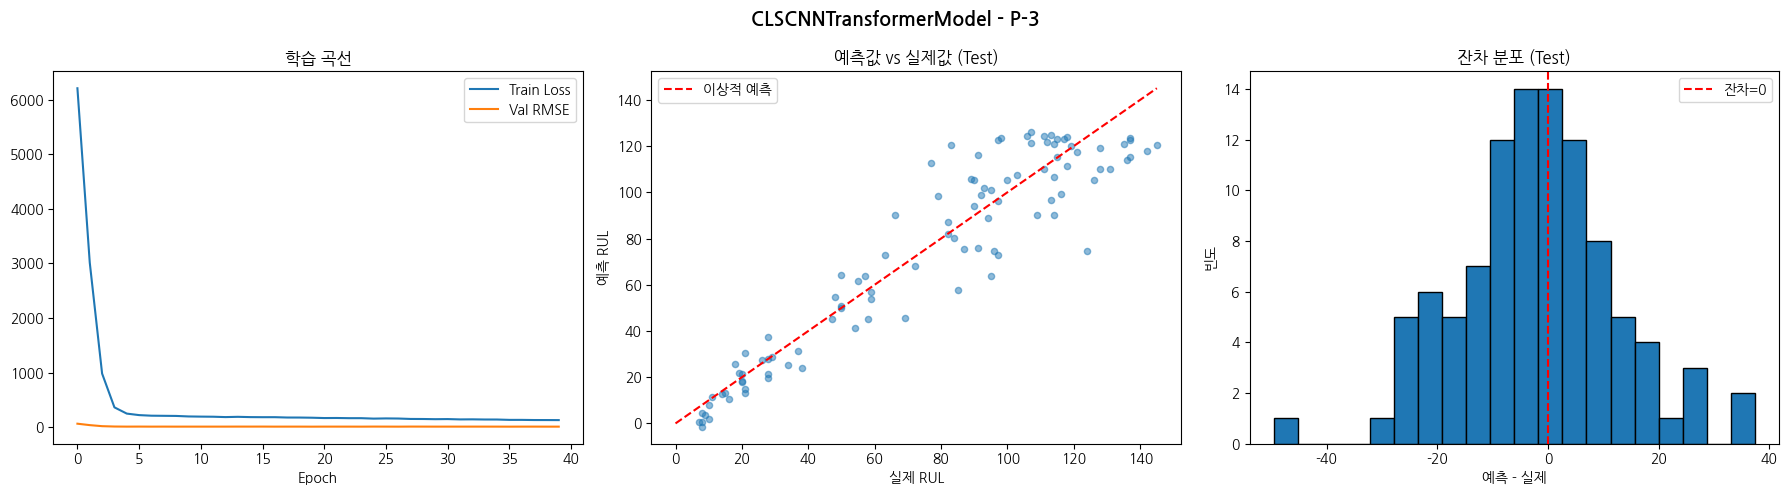

(np.float32(14.659389), np.float32(328.21976))

In [14]:
# P-3: CLS Token
# 시퀀스 앞에 학습 가능한 토큰을 추가하고 해당 토큰의 출력으로 예측
# BERT에서 제안된 방식으로, 전체 시퀀스 정보를 하나로 요약하는 역할

class CLSCNNTransformerModel(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)
        x = self.dropout(x[:, 0, :])
        return self.fc(x).squeeze(1)

run_experiment_transformer("P-3", CLSCNNTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

Epoch  10 | train_loss: 194.7947 | val_rmse: 11.8753
Epoch  20 | train_loss: 172.6684 | val_rmse: 11.5453
Epoch  30 | train_loss: 157.9252 | val_rmse: 11.9531
Epoch  40 | train_loss: 138.2790 | val_rmse: 12.0378
Epoch  50 | train_loss: 125.2093 | val_rmse: 11.9236
Epoch  60 | train_loss: 116.7557 | val_rmse: 12.1923


2026/05/01 14:16:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Early stopping at epoch 65


2026/05/01 14:16:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



[P-5] 최종 결과
  Test RMSE  : 15.8857
  NASA Score : 503.81


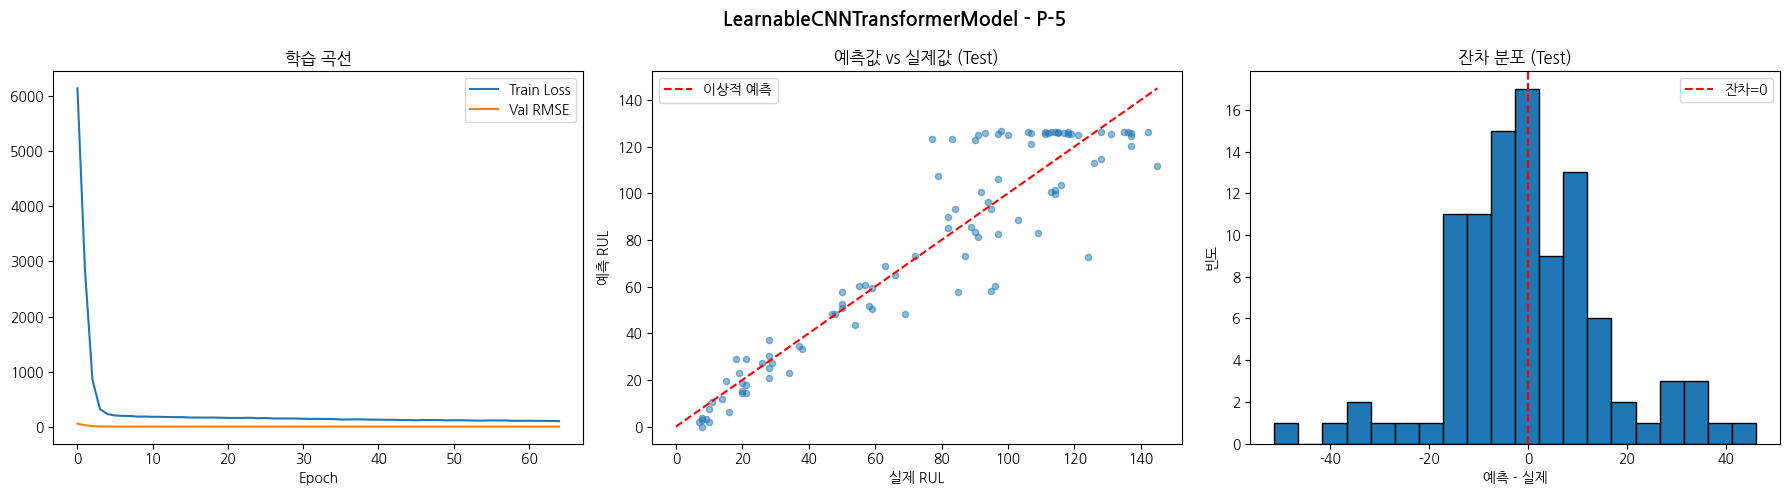

(np.float32(15.885685), np.float32(503.80518))

In [16]:
# P-4: 층수 3 + Sinusoidal PE
# H-1(층수 3)과 P-1(Sinusoidal PE)이 각각 베이스라인 대비 성능 개선을 보임
# → 두 요소를 결합했을 때 시너지 효과가 있는지 확인하기 위한 실험
# run_experiment_transformer("P-4", SinusoidalCNNTransformerModel, hidden_size=64, num_layers=3, dropout=0.2, nhead=4)

# P-5: 층수 3 + Learnable PE
# H-1(층수 3)과 P-2(Learnable PE)이 각각 베이스라인 대비 성능 개선을 보임
# → 두 요소를 결합했을 때 시너지 효과가 있는지 확인하기 위한 실험
# run_experiment_transformer("P-5", LearnableCNNTransformerModel, hidden_size=64, num_layers=3, dropout=0.2, nhead=4)